Cellule 1 — Installer les librairies nécessaires

In [ ]:
!pip install kagglehub ucimlrepo --quiet

Cellule 2 — Télécharger Tétouan City Power Consumption (le plus simple, pas d'authentification)

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Tétouan City Power Consumption (UCI id=849)
tetouan = fetch_ucirepo(id=849)

df_tetouan = pd.concat([tetouan.data.features, tetouan.data.targets], axis=1)
print("Tétouan - shape:", df_tetouan.shape)
print(df_tetouan.head())

df_tetouan.to_csv('/content/tetouan_power_consumption.csv', index=False)

Tétouan - shape: (52416, 9)
        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   
3          0.096               28228.86076                18361.09422   
4          0.085               27335.69620                17872.34043   

   Zone 3  Power Consumption  
0                20240.96386  
1 

Cellule 3 — Télécharger UCI Household Power Consumption (France)

In [ ]:
# Individual Household Electric Power Consumption (UCI id=235)
household = fetch_ucirepo(id=235)

df_household = pd.concat([household.data.features, household.data.targets], axis=1)
print("Household FR - shape:", df_household.shape)
print(df_household.head())

df_household.to_csv('/content/household_power_consumption_fr.csv', index=False)

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Household FR - shape: (2075259, 9)
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


In [ ]:
df_household['datetime'] = pd.to_datetime(
    df_household['Date'] + ' ' + df_household['Time'], dayfirst=True)

for c in ['Global_active_power', 'Global_reactive_power', 'Voltage',
          'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    df_household[c] = pd.to_numeric(df_household[c], errors='coerce')

print(df_household.isna().sum())
print(df_household['Voltage'].describe())  # vérifier la plage réelle de tension (doit tourner autour de 230-240V)

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
datetime                     0
dtype: int64
count    2.049280e+06
mean     2.408399e+02
std      3.239987e+00
min      2.232000e+02
25%      2.389900e+02
50%      2.410100e+02
75%      2.428900e+02
max      2.541500e+02
Name: Voltage, dtype: float64


Cellule 4 — Authentification Kaggle

In [ ]:
import kagglehub
kagglehub.login()


Cellule 5 — Télécharger Smart Meters in London

In [ ]:
import kagglehub

path = kagglehub.dataset_download("jeanmidev/smart-meters-in-london")
print("Fichiers téléchargés dans :", path)

import os
for f in os.listdir(path):
    print(f)

100%|██████████| 1.17G/1.17G [00:31<00:00, 40.2MB/s]

Extracting files...


Fichiers téléchargés dans : /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21
daily_dataset.csv
halfhourly_dataset
daily_dataset
informations_households.csv
weather_hourly_darksky.csv
darksky_parameters_documentation.html
uk_bank_holidays.csv
hhblock_dataset
acorn_details.csv
weather_daily_darksky.csv


Cellule 6 — Explorer les fichiers de Londres et choisir notre "quartier"

In [ ]:
import os

# On regarde la structure exacte du dataset téléchargé
for root, dirs, filenames in os.walk(path):
    for name in dirs:
        print("DOSSIER:", os.path.join(root, name))
    for name in filenames:
        print("FICHIER:", os.path.join(root, name))

DOSSIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/halfhourly_dataset
DOSSIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/daily_dataset
DOSSIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/hhblock_dataset
FICHIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/daily_dataset.csv
FICHIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/informations_households.csv
FICHIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/weather_hourly_darksky.csv
FICHIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/darksky_parameters_documentation.html
FICHIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/uk_bank_holidays.csv
FICHIER: /root/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21/acorn_details.csv
FICHIER: /root/.cache/kaggl

Cellule 7 — Charger un premier aperçu de chaque dataset

In [ ]:
# Informations sur les foyers (pour choisir un sous-ensemble cohérent = notre quartier)
df_info = pd.read_csv(os.path.join(path, 'informations_households.csv'))
print(df_info.shape)
print(df_info.head())

# Détails ACORN (catégories socio-économiques)
df_acorn = pd.read_csv(os.path.join(path, 'acorn_details.csv'), encoding='latin-1')
print(df_acorn.shape)
print(df_acorn.head(15))

(5566, 5)
       LCLid stdorToU    Acorn Acorn_grouped     file
0  MAC005492      ToU   ACORN-        ACORN-  block_0
1  MAC001074      ToU   ACORN-        ACORN-  block_0
2  MAC000002      Std  ACORN-A      Affluent  block_0
3  MAC003613      Std  ACORN-A      Affluent  block_0
4  MAC003597      Std  ACORN-A      Affluent  block_0
(826, 20)
   MAIN CATEGORIES CATEGORIES         REFERENCE  ACORN-A  ACORN-B  ACORN-C  \
0       POPULATION        Age           Age 0-4     77.0     83.0     72.0   
1       POPULATION        Age          Age 5-17    117.0    109.0     87.0   
2       POPULATION        Age         Age 18-24     64.0     73.0     67.0   
3       POPULATION        Age         Age 25-34     52.0     63.0     62.0   
4       POPULATION        Age         Age 35-49    102.0    105.0     91.0   
5       POPULATION        Age         Age 50-64    124.0    121.0    120.0   
6       POPULATION        Age        Aged 65-74    125.0    120.0    152.0   
7       POPULATION        Age   

In [ ]:
import os

# Structure exacte du dossier téléchargé
for root, dirs, filenames in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    for f in filenames:
        print('  ' * (level + 1) + f)

21/
  daily_dataset.csv
  informations_households.csv
  weather_hourly_darksky.csv
  darksky_parameters_documentation.html
  uk_bank_holidays.csv
  acorn_details.csv
  weather_daily_darksky.csv
  halfhourly_dataset/
    halfhourly_dataset/
      block_60.csv
      block_28.csv
      block_99.csv
      block_95.csv
      block_97.csv
      block_83.csv
      block_38.csv
      block_45.csv
      block_86.csv
      block_7.csv
      block_41.csv
      block_46.csv
      block_77.csv
      block_47.csv
      block_23.csv
      block_0.csv
      block_65.csv
      block_88.csv
      block_56.csv
      block_58.csv
      block_21.csv
      block_85.csv
      block_72.csv
      block_5.csv
      block_30.csv
      block_31.csv
      block_93.csv
      block_89.csv
      block_70.csv
      block_82.csv
      block_63.csv
      block_29.csv
      block_14.csv
      block_92.csv
      block_50.csv
      block_53.csv
      block_90.csv
      block_19.csv
      block_76.csv
      block_9.csv
    

In [ ]:
# Un aperçu du fichier halfhourly (le plus important pour nous : relevés réels par foyer)
halfhourly_dir = os.path.join(path, 'halfhourly_dataset', 'halfhourly_dataset')
first_file = os.listdir(halfhourly_dir)[0]
df_hh_sample = pd.read_csv(os.path.join(halfhourly_dir, first_file))
print(first_file)
print(df_hh_sample.shape)
print(df_hh_sample.head())

block_60.csv
(1371713, 3)
       LCLid                         tstp energy(kWh/hh)
0  MAC000118  2011-12-14 13:00:00.0000000         0.142 
1  MAC000118  2011-12-14 13:30:00.0000000         0.103 
2  MAC000118  2011-12-14 14:00:00.0000000         0.207 
3  MAC000118  2011-12-14 14:30:00.0000000         0.089 
4  MAC000118  2011-12-14 15:00:00.0000000         0.127 


In [ ]:
# Météo horaire (à comparer plus tard avec la météo réelle de Tunis)
df_weather = pd.read_csv(os.path.join(path, 'weather_hourly_darksky.csv'))
print(df_weather.columns.tolist())
print(df_weather.head())

['visibility', 'windBearing', 'temperature', 'time', 'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed', 'precipType', 'icon', 'humidity', 'summary']
   visibility  windBearing  temperature                 time  dewPoint  \
0        5.97          104        10.24  2011-11-11 00:00:00      8.86   
1        4.88           99         9.76  2011-11-11 01:00:00      8.83   
2        3.70           98         9.46  2011-11-11 02:00:00      8.79   
3        3.12           99         9.23  2011-11-11 03:00:00      8.63   
4        1.85          111         9.26  2011-11-11 04:00:00      9.21   

   pressure  apparentTemperature  windSpeed precipType                 icon  \
0   1016.76                10.24       2.77       rain  partly-cloudy-night   
1   1016.63                 8.24       2.95       rain  partly-cloudy-night   
2   1016.36                 7.76       3.17       rain  partly-cloudy-night   
3   1016.28                 7.44       3.25       rain                  fog   
4 

In [ ]:
# Jours fériés UK (à ignorer/remplacer plus tard par le calendrier tunisien si besoin de cohérence)
df_holidays = pd.read_csv(os.path.join(path, 'uk_bank_holidays.csv'))
print(df_holidays.head())

  Bank holidays                                          Type
0    2012-12-26                                    Boxing Day
1    2012-12-25                                 Christmas Day
2    2012-08-27                           Summer bank holiday
3    2012-05-06  Queen?s Diamond Jubilee (extra bank holiday)
4    2012-04-06          Spring bank holiday (substitute day)


Exploration de Tétouan

In [ ]:
df_tetouan['DateTime'] = pd.to_datetime(df_tetouan['DateTime'])

print(df_tetouan.dtypes)
print("\nPlage temporelle réelle :", df_tetouan['DateTime'].min(), "à", df_tetouan['DateTime'].max())
print("Nombre de jours couverts :", (df_tetouan['DateTime'].max() - df_tetouan['DateTime'].min()).days)

DateTime                     datetime64[ns]
Temperature                         float64
Humidity                            float64
Wind Speed                          float64
general diffuse flows               float64
diffuse flows                       float64
Zone 1 Power Consumption            float64
Zone 2  Power Consumption           float64
Zone 3  Power Consumption           float64
dtype: object

Plage temporelle réelle : 2017-01-01 00:00:00 à 2017-12-30 23:50:00
Nombre de jours couverts : 363


In [ ]:
# Vérification des types et valeurs manquantes après conversion
print(df_tetouan.dtypes)
print("\nValeurs manquantes par colonne :")
print(df_tetouan.isna().sum())

print("\nDoublons de timestamp :", df_tetouan['DateTime'].duplicated().sum())
print("Plage temporelle :", df_tetouan['DateTime'].min(), "à", df_tetouan['DateTime'].max())

DateTime                     datetime64[ns]
Temperature                         float64
Humidity                            float64
Wind Speed                          float64
general diffuse flows               float64
diffuse flows                       float64
Zone 1 Power Consumption            float64
Zone 2  Power Consumption           float64
Zone 3  Power Consumption           float64
dtype: object

Valeurs manquantes par colonne :
DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64

Doublons de timestamp : 0
Plage temporelle : 2017-01-01 00:00:00 à 2017-12-30 23:50:00


In [ ]:
# Statistiques descriptives complètes
df_tetouan.describe()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,2017-04-01 23:57:30,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,2017-07-01 23:55:00,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,2017-09-30 23:52:30,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,2017-12-30 23:50:00,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360
std,NaN,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099


In [ ]:
# Vérification de valeurs physiquement impossibles (négatives, nulles suspectes)
cols_numeriques = ['Temperature', 'Humidity', 'Wind Speed',
                    'general diffuse flows', 'diffuse flows',
                    'Zone 1 Power Consumption', 'Zone 2  Power Consumption',
                    'Zone 3  Power Consumption']

for c in cols_numeriques:
    n_neg = (df_tetouan[c] < 0).sum()
    print(f"{c} : {n_neg} valeurs négatives, min={df_tetouan[c].min():.2f}, max={df_tetouan[c].max():.2f}")

Temperature : 0 valeurs négatives, min=3.25, max=40.01
Humidity : 0 valeurs négatives, min=11.34, max=94.80
Wind Speed : 0 valeurs négatives, min=0.05, max=6.48
general diffuse flows : 0 valeurs négatives, min=0.00, max=1163.00
diffuse flows : 0 valeurs négatives, min=0.01, max=936.00
Zone 1 Power Consumption : 0 valeurs négatives, min=13895.70, max=52204.40
Zone 2  Power Consumption : 0 valeurs négatives, min=8560.08, max=37408.86
Zone 3  Power Consumption : 0 valeurs négatives, min=5935.17, max=47598.33


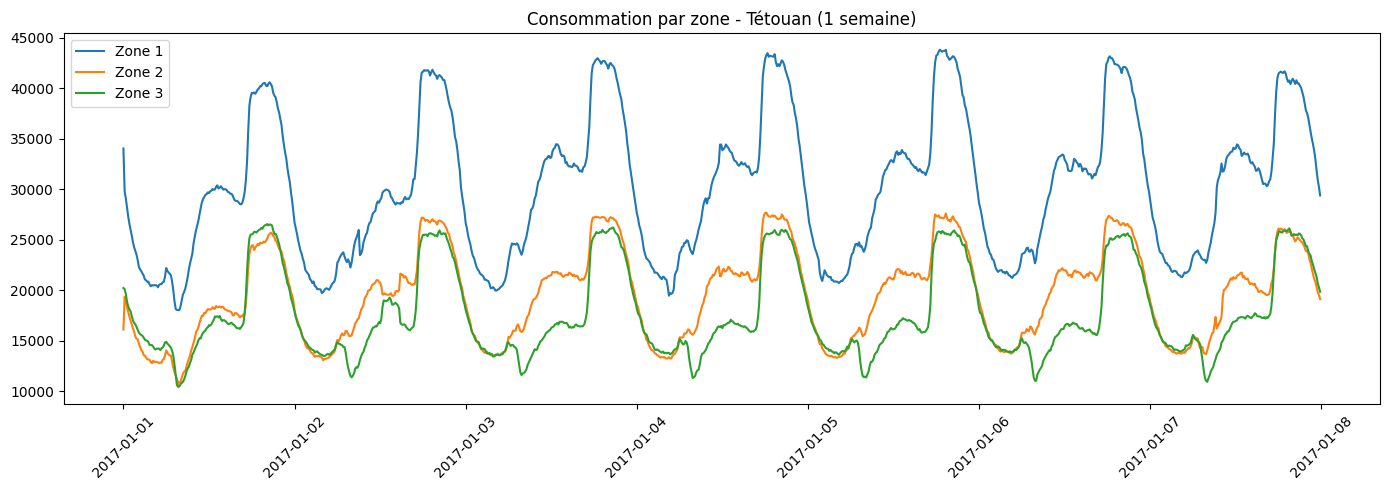

In [ ]:
import matplotlib.pyplot as plt

# Visualisation de la consommation des 3 zones sur une semaine type
df_plot = df_tetouan.set_index('DateTime').iloc[:1008]  # 1 semaine (10min * 1008 = 7j)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_plot.index, df_plot['Zone 1 Power Consumption'], label='Zone 1')
ax.plot(df_plot.index, df_plot['Zone 2  Power Consumption'], label='Zone 2')
ax.plot(df_plot.index, df_plot['Zone 3  Power Consumption'], label='Zone 3')
ax.set_title("Consommation par zone - Tétouan (1 semaine)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

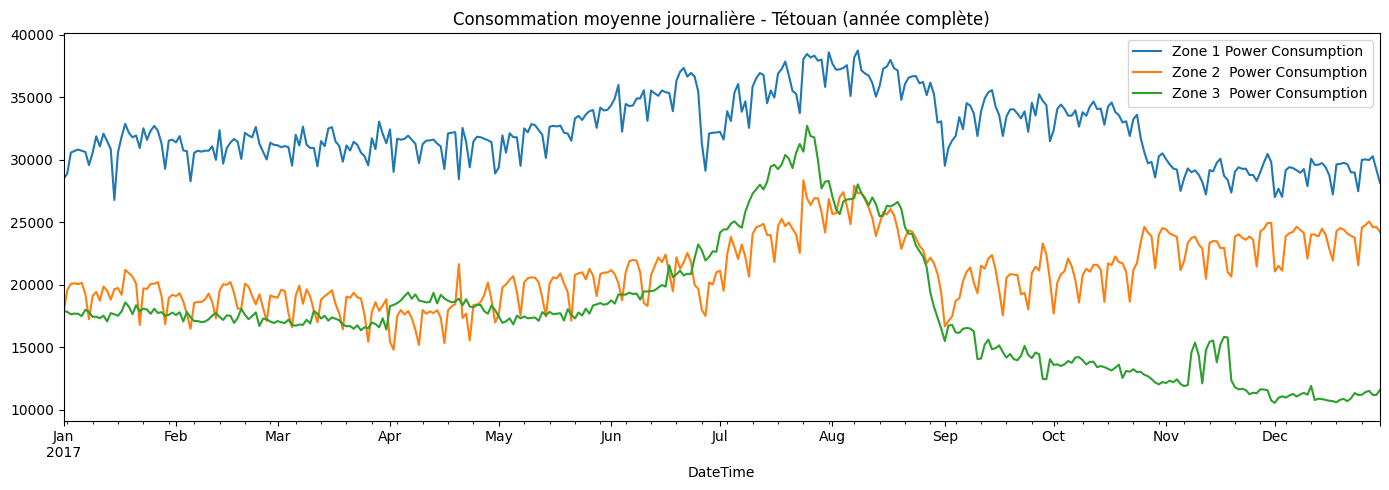

In [ ]:
df_tetouan['DateTime'] = pd.to_datetime(df_tetouan['DateTime'])
# Vue d'ensemble sur toute la période (pour repérer la saisonnalité)
df_daily = df_tetouan.set_index('DateTime')[['Zone 1 Power Consumption',
                                               'Zone 2  Power Consumption',
                                               'Zone 3  Power Consumption']].resample('D').mean()
df_daily.plot(figsize=(14, 5), title="Consommation moyenne journalière - Tétouan (année complète)")
plt.tight_layout()
plt.show()

In [ ]:
# Corrélation entre météo et consommation (utile pour la logique "genuine grid event")
correlation = df_tetouan[cols_numeriques].corr()
print(correlation[['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']])

                           Zone 1 Power Consumption  \
Temperature                                0.440221   
Humidity                                  -0.287421   
Wind Speed                                 0.167444   
general diffuse flows                      0.187965   
diffuse flows                              0.080274   
Zone 1 Power Consumption                   1.000000   
Zone 2  Power Consumption                  0.834519   
Zone 3  Power Consumption                  0.750733   

                           Zone 2  Power Consumption  \
Temperature                                 0.382428   
Humidity                                   -0.294961   
Wind Speed                                  0.146413   
general diffuse flows                       0.157223   
diffuse flows                               0.044667   
Zone 1 Power Consumption                    0.834519   
Zone 2  Power Consumption                   1.000000   
Zone 3  Power Consumption                   0.570932   


In [ ]:
for zone in ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']:
    # Compte les séquences de valeurs strictement identiques consécutives
    is_same_as_prev = df_tetouan[zone].diff() == 0
    # Nombre max de répétitions consécutives
    groups = (is_same_as_prev != is_same_as_prev.shift()).cumsum()
    max_run = is_same_as_prev.groupby(groups).sum().max()
    print(f"{zone} : plus longue série de valeurs identiques consécutives = {max_run}")

Zone 1 Power Consumption : plus longue série de valeurs identiques consécutives = 2
Zone 2  Power Consumption : plus longue série de valeurs identiques consécutives = 2
Zone 3  Power Consumption : plus longue série de valeurs identiques consécutives = 2


In [ ]:
# Recherche de sauts brusques suspects (discontinuités trop grandes d'un pas de temps à l'autre)
for zone in ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']:
    diffs = df_tetouan[zone].diff().abs()
    seuil = diffs.quantile(0.999)  # 0.1% des variations les plus extrêmes
    print(f"{zone} : 99.9e percentile de variation = {seuil:.1f}, max = {diffs.max():.1f}")

Zone 1 Power Consumption : 99.9e percentile de variation = 3654.9, max = 19344.7
Zone 2  Power Consumption : 99.9e percentile de variation = 2447.1, max = 7813.4
Zone 3  Power Consumption : 99.9e percentile de variation = 2828.1, max = 7133.7


In [ ]:
idx_max_jump = df_tetouan['Zone 1 Power Consumption'].diff().abs().idxmax()
print(df_tetouan.loc[idx_max_jump-2:idx_max_jump+2, ['DateTime', 'Zone 1 Power Consumption']])

                 DateTime  Zone 1 Power Consumption
15767 2017-04-20 11:50:00               37015.28525
15768 2017-04-20 12:00:00               36159.65554
15769 2017-04-20 12:10:00               16814.98385
15770 2017-04-20 12:20:00               17794.61787
15771 2017-04-20 12:30:00               26995.73735


In [ ]:
def detect_isolated_glitches(series, seuil_ecart_type=6):
    """Détecte les points isolés qui s'écartent fortement de leurs deux voisins
    immédiats puis reviennent vers une valeur proche de la tendance."""
    diff = series.diff()
    z = (diff - diff.mean()) / diff.std()
    # Point suspect si sa variation ET la variation du point suivant sont extrêmes
    # et de signe opposé (chute puis remontée, ou l'inverse)
    suspect = (z.abs() > seuil_ecart_type) & (z.shift(-1).abs() > seuil_ecart_type / 2)
    return suspect

glitches = {}
for zone in ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']:
    mask = detect_isolated_glitches(df_tetouan[zone])
    glitches[zone] = df_tetouan[mask]
    print(f"{zone} : {mask.sum()} glitch(s) isolé(s) détecté(s)")

print(glitches['Zone 1 Power Consumption'][['DateTime', 'Zone 1 Power Consumption']])

Zone 1 Power Consumption : 6 glitch(s) isolé(s) détecté(s)
Zone 2  Power Consumption : 17 glitch(s) isolé(s) détecté(s)
Zone 3  Power Consumption : 86 glitch(s) isolé(s) détecté(s)
                 DateTime  Zone 1 Power Consumption
2011  2017-01-14 23:10:00               25300.25316
18260 2017-05-07 19:20:00               39193.18033
21669 2017-05-31 11:30:00               25318.81967
34716 2017-08-30 02:00:00               18283.68479
42730 2017-10-24 17:40:00               41391.33479
43306 2017-10-28 17:40:00               37742.49453


In [ ]:
df_tetouan_clean = df_tetouan.copy()

for zone in ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']:
    mask = detect_isolated_glitches(df_tetouan[zone])
    df_tetouan_clean.loc[mask, zone] = None

df_tetouan_clean[['Zone 1 Power Consumption', 'Zone 2  Power Consumption',
                   'Zone 3  Power Consumption']] = df_tetouan_clean[
    ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
].interpolate(method='linear')

print("Vérification post-correction :")
print(df_tetouan_clean.loc[15765:15773, ['DateTime', 'Zone 1 Power Consumption']])

Vérification post-correction :
                 DateTime  Zone 1 Power Consumption
15765 2017-04-20 11:30:00               36097.65339
15766 2017-04-20 11:40:00               36544.06889
15767 2017-04-20 11:50:00               37015.28525
15768 2017-04-20 12:00:00               36159.65554
15769 2017-04-20 12:10:00               16814.98385
15770 2017-04-20 12:20:00               17794.61787
15771 2017-04-20 12:30:00               26995.73735
15772 2017-04-20 12:40:00               26822.13132
15773 2017-04-20 12:50:00               26226.91066


In [ ]:
def hampel_filter(series, window=5, n_sigmas=4):
    rolling_median = series.rolling(window, center=True, min_periods=1).median()
    ecart = (series - rolling_median).abs()
    mad = ecart.rolling(window, center=True, min_periods=1).median()
    seuil = n_sigmas * 1.4826 * mad  # 1.4826 = facteur de normalisation du MAD
    return ecart > seuil

zones = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
glitches_v2 = {}

for zone in zones:
    mask = hampel_filter(df_tetouan[zone])
    glitches_v2[zone] = mask
    print(f"{zone} : {mask.sum()} point(s) détecté(s)")

# Vérifier que notre point du 20/04 est bien capté cette fois
print(df_tetouan.loc[15767:15772, ['DateTime', 'Zone 1 Power Consumption']])
print("Détecté :", glitches_v2['Zone 1 Power Consumption'].loc[15769])

Zone 1 Power Consumption : 5714 point(s) détecté(s)
Zone 2  Power Consumption : 5645 point(s) détecté(s)
Zone 3  Power Consumption : 5427 point(s) détecté(s)
                 DateTime  Zone 1 Power Consumption
15767 2017-04-20 11:50:00               37015.28525
15768 2017-04-20 12:00:00               36159.65554
15769 2017-04-20 12:10:00               16814.98385
15770 2017-04-20 12:20:00               17794.61787
15771 2017-04-20 12:30:00               26995.73735
15772 2017-04-20 12:40:00               26822.13132
Détecté : True


In [ ]:
# Application de la correction avec cette meilleure détection
df_tetouan_clean = df_tetouan.copy()

for zone in zones:
    mask = hampel_filter(df_tetouan[zone])
    df_tetouan_clean.loc[mask, zone] = None

df_tetouan_clean[zones] = df_tetouan_clean[zones].interpolate(method='linear')

# Vérification finale sur notre cas de référence
print(df_tetouan_clean.loc[15765:15773, ['DateTime', 'Zone 1 Power Consumption']])

                 DateTime  Zone 1 Power Consumption
15765 2017-04-20 11:30:00              36097.653390
15766 2017-04-20 11:40:00              36556.469320
15767 2017-04-20 11:50:00              37015.285250
15768 2017-04-20 12:00:00              36159.655540
15769 2017-04-20 12:10:00              33105.016143
15770 2017-04-20 12:20:00              30050.376747
15771 2017-04-20 12:30:00              26995.737350
15772 2017-04-20 12:40:00              26822.131320
15773 2017-04-20 12:50:00              26226.910660


In [ ]:
def hampel_filter_v2(series, window=9, n_sigmas=6, seuil_relatif=0.15):
    rolling_median = series.rolling(window, center=True, min_periods=1).median()
    ecart = (series - rolling_median).abs()
    mad = ecart.rolling(window, center=True, min_periods=1).median()
    seuil_stat = n_sigmas * 1.4826 * mad

    critere_statistique = ecart > seuil_stat
    critere_amplitude = ecart / rolling_median.abs().clip(lower=1) > seuil_relatif

    return critere_statistique & critere_amplitude

zones = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
glitches_v3 = {}

for zone in zones:
    mask = hampel_filter_v2(df_tetouan[zone])
    glitches_v3[zone] = mask
    print(f"{zone} : {mask.sum()} point(s) détecté(s) ({100*mask.sum()/len(df_tetouan):.2f}%)")

# Vérifier que notre cas de référence du 20/04 est toujours bien capté
print("Détecté (20/04 12:10) :", glitches_v3['Zone 1 Power Consumption'].loc[15769])

Zone 1 Power Consumption : 2 point(s) détecté(s) (0.00%)
Zone 2  Power Consumption : 1 point(s) détecté(s) (0.00%)
Zone 3  Power Consumption : 13 point(s) détecté(s) (0.02%)
Détecté (20/04 12:10) : True


In [ ]:
df_tetouan_clean = df_tetouan.copy()

for zone in zones:
    mask = hampel_filter_v2(df_tetouan[zone])
    df_tetouan_clean.loc[mask, zone] = None

df_tetouan_clean[zones] = df_tetouan_clean[zones].interpolate(method='linear')

# Vérification finale : plus aucun NaN, notre point de référence corrigé
print("NaN restants :", df_tetouan_clean[zones].isna().sum().sum())
print(df_tetouan_clean.loc[15765:15773, ['DateTime', 'Zone 1 Power Consumption']])

NaN restants : 0
                 DateTime  Zone 1 Power Consumption
15765 2017-04-20 11:30:00              36097.653390
15766 2017-04-20 11:40:00              36544.068890
15767 2017-04-20 11:50:00              37015.285250
15768 2017-04-20 12:00:00              36159.655540
15769 2017-04-20 12:10:00              33105.016143
15770 2017-04-20 12:20:00              30050.376747
15771 2017-04-20 12:30:00              26995.737350
15772 2017-04-20 12:40:00              26822.131320
15773 2017-04-20 12:50:00              26226.910660


In [ ]:
# Sauvegarde de la version propre dans Colab
df_tetouan_clean.to_csv('/content/tetouan_clean.csv', index=False)
print("Sauvegardé :", df_tetouan_clean.shape)

Sauvegardé : (52416, 9)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/EnergyMind_TSYP14/data', exist_ok=True)
df_tetouan_clean.to_csv('/content/drive/MyDrive/EnergyMind_TSYP14/data/tetouan_clean.csv', index=False)
print("Sauvegardé sur Drive")

Mounted at /content/drive
Sauvegardé sur Drive


UCI Household Power Consumption (France)

* 2 075 259 lignes, 1 minute de granularité, du 16/12/2006 au 26/11/2010
* 9 colonnes : Date, Time, Global_active_power (kW), Global_reactive_power (kVAR), Voltage (V), Global_intensity (A), Sub_metering_1/2/3 (Wh, circuits cuisine/buanderie/chauffe-eau)
* 25 979 lignes avec valeurs manquantes simultanées sur les 7 colonnes de mesure (jamais partielles) — cohérent avec les ~1,25% documentés officiellement par UCI, donc pas une anomalie de notre collecte
* Voltage déjà vérifié : moyenne 240,8V, min 223,2V, max 254,15V — dans la tolérance européenne 230V ±10% (207-253V), propre

Structure des trous

In [ ]:
df_household_sorted = df_household.sort_values('datetime').reset_index(drop=True)
is_missing = df_household_sorted['Global_active_power'].isna()

groups = (is_missing != is_missing.shift()).cumsum()
missing_runs = is_missing.groupby(groups).sum()
missing_runs = missing_runs[missing_runs > 0]

print("Nombre de blocs de trous distincts :", len(missing_runs))
print("Taille du plus grand bloc de trous (en minutes) :", missing_runs.max())
print(missing_runs.describe())

Nombre de blocs de trous distincts : 71
Taille du plus grand bloc de trous (en minutes) : 7226
count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
Name: Global_active_power, dtype: float64


Doublons et cohérence temporelle

In [ ]:
print("Doublons de timestamp :", df_household_sorted['datetime'].duplicated().sum())

# Vérifier que le pas de temps est bien régulier (1 minute) hors trous
ecarts = df_household_sorted['datetime'].diff().dropna()
print(ecarts.value_counts().head())

Doublons de timestamp : 0
datetime
0 days 00:01:00    2075258
Name: count, dtype: int64


Cohérence physique entre les colonnes

In [ ]:
S_calculee = (df_household['Voltage'] * df_household['Global_intensity']) / 1000
S_theorique = (df_household['Global_active_power']**2 + df_household['Global_reactive_power']**2) ** 0.5

ecart_relatif_v2 = (S_theorique - S_calculee).abs() / S_calculee.replace(0, pd.NA)
print(ecart_relatif_v2.describe())
print("Lignes avec écart > 20% :", (ecart_relatif_v2 > 0.20).sum())

count    2.049280e+06
mean     3.982111e-02
std      6.373870e-02
min      0.000000e+00
25%      7.545144e-03
50%      2.001758e-02
75%      5.203950e-02
max      7.512422e-01
dtype: float64
Lignes avec écart > 20% : 31557


Valeurs négatives ou physiquement impossibles

In [ ]:
cols_positives = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for c in cols_positives:
    n_neg = (df_household[c] < 0).sum()
    print(f"{c} : {n_neg} valeurs négatives, min={df_household[c].min():.3f}, max={df_household[c].max():.3f}")

Global_active_power : 0 valeurs négatives, min=0.076, max=11.122
Global_reactive_power : 0 valeurs négatives, min=0.000, max=1.390
Voltage : 0 valeurs négatives, min=223.200, max=254.150
Global_intensity : 0 valeurs négatives, min=0.200, max=48.400
Sub_metering_1 : 0 valeurs négatives, min=0.000, max=88.000
Sub_metering_2 : 0 valeurs négatives, min=0.000, max=80.000
Sub_metering_3 : 0 valeurs négatives, min=0.000, max=31.000


Recherche de glitches isolés

In [ ]:
def hampel_filter_v2(series, window=9, n_sigmas=6, seuil_relatif=0.15):
    rolling_median = series.rolling(window, center=True, min_periods=1).median()
    ecart = (series - rolling_median).abs()
    mad = ecart.rolling(window, center=True, min_periods=1).median()
    seuil_stat = n_sigmas * 1.4826 * mad
    critere_statistique = ecart > seuil_stat
    critere_amplitude = ecart / rolling_median.abs().clip(lower=0.01) > seuil_relatif
    return critere_statistique & critere_amplitude

mask_glitch = hampel_filter_v2(df_household_sorted['Global_active_power'])
print(f"Glitches détectés : {mask_glitch.sum()} ({100*mask_glitch.sum()/len(df_household_sorted):.3f}%)")

Glitches détectés : 55761 (2.687%)


Trous manquants

In [ ]:
# Identifier les blocs de trous et leur position temporelle exacte
is_missing = df_household_sorted['Global_active_power'].isna()
groups = (is_missing != is_missing.shift()).cumsum()

blocs = df_household_sorted.groupby(groups).agg(
    debut=('datetime', 'first'),
    fin=('datetime', 'last'),
    taille=('datetime', 'size'),
    est_trou=('Global_active_power', lambda x: x.isna().all())
)
blocs_trous = blocs[blocs['est_trou']].sort_values('taille', ascending=False)
print(blocs_trous.head(15))

                                  debut                 fin  taille  est_trou
Global_active_power                                                          
138                 2010-08-17 21:02:00 2010-08-22 21:27:00    7226      True
140                 2010-09-25 03:56:00 2010-09-28 19:12:00    5237      True
14                  2007-04-28 00:21:00 2007-04-30 14:23:00    3723      True
100                 2009-06-13 00:30:00 2009-06-15 07:34:00    3305      True
118                 2010-01-12 14:53:00 2010-01-14 19:01:00    3129      True
126                 2010-03-20 03:52:00 2010-03-21 13:38:00    2027      True
104                 2009-08-13 05:00:00 2009-08-13 19:50:00     891      True
32                  2007-07-15 16:49:00 2007-07-15 18:11:00      83      True
78                  2008-12-10 10:48:00 2008-12-10 11:57:00      70      True
34                  2007-07-15 18:21:00 2007-07-15 19:07:00      47      True
70                  2008-10-25 10:28:00 2008-10-25 11:10:00     

In [ ]:
mask_glitch = hampel_filter_v2(df_household_sorted['Global_active_power'])
exemples = df_household_sorted[mask_glitch].head(10)
print(exemples[['datetime', 'Global_active_power', 'Global_intensity',
                 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']])

               datetime  Global_active_power  Global_intensity  \
23  2006-12-16 17:47:00                5.174              22.0   
61  2006-12-16 18:25:00                4.870              20.8   
62  2006-12-16 18:26:00                4.868              20.8   
63  2006-12-16 18:27:00                4.866              20.8   
71  2006-12-16 18:35:00                6.072              26.4   
81  2006-12-16 18:45:00                4.200              17.8   
82  2006-12-16 18:46:00                4.204              17.8   
211 2006-12-16 20:55:00                1.832               8.4   
212 2006-12-16 20:56:00                2.044               9.4   
218 2006-12-16 21:02:00                1.692               7.8   

     Sub_metering_1  Sub_metering_2  Sub_metering_3  
23              0.0             0.0            17.0  
61              0.0             1.0            17.0  
62              0.0             1.0            17.0  
63              0.0             1.0            17.0  
71 

In [ ]:
# Marquer le type de trou : court (interpolable) vs long (coupure réelle à préserver telle quelle)
SEUIL_COURT_MINUTES = 120  # 2h — au-dessus des 7 gros blocs (>800 min), en dessous du reste (<100 min)

groups = (is_missing != is_missing.shift()).cumsum()
taille_bloc = df_household_sorted.groupby(groups)['datetime'].transform('size')

est_trou_court = is_missing & (taille_bloc <= SEUIL_COURT_MINUTES)
est_trou_long = is_missing & (taille_bloc > SEUIL_COURT_MINUTES)

print("Lignes en trou court (à interpoler) :", est_trou_court.sum())
print("Lignes en trou long (coupure réelle, non interpolées) :", est_trou_long.sum())

Lignes en trou court (à interpoler) : 441
Lignes en trou long (coupure réelle, non interpolées) : 25538


In [ ]:
df_household_clean = df_household_sorted.copy()
cols_mesure = ['Global_active_power', 'Global_reactive_power', 'Voltage',
               'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# Interpolation simple sur toute la série
df_household_clean[cols_mesure] = df_household_clean[cols_mesure].interpolate(method='linear')

# Correction : on réimpose NaN explicitement sur les trous longs, peu importe
# ce que interpolate() a fait dessus — c'est notre propre masque qui fait foi, pas pandas
df_household_clean.loc[est_trou_long.values, cols_mesure] = None

print("NaN restants :", df_household_clean[cols_mesure].isna().sum())
print("Doit être exactement 25538 sur chaque colonne")

NaN restants : Global_active_power      25538
Global_reactive_power    25538
Voltage                  25538
Global_intensity         25538
Sub_metering_1           25538
Sub_metering_2           25538
Sub_metering_3           25538
dtype: int64
Doit être exactement 25538 sur chaque colonne


In [ ]:
df_household_clean['etait_manquant'] = is_missing.values
df_household_clean['type_trou'] = 'aucun'
df_household_clean.loc[est_trou_court.values, 'type_trou'] = 'court_interpole'
df_household_clean.loc[est_trou_long.values, 'type_trou'] = 'long_non_comble'

print(df_household_clean[cols_mesure].isna().sum())
print(df_household_clean['type_trou'].value_counts())

df_household_clean.to_csv('/content/household_fr_clean.csv', index=False)
df_household_clean.to_csv('/content/drive/MyDrive/EnergyMind_TSYP14/data/household_fr_clean.csv', index=False)
print(df_household_clean.shape)

Global_active_power      25538
Global_reactive_power    25538
Voltage                  25538
Global_intensity         25538
Sub_metering_1           25538
Sub_metering_2           25538
Sub_metering_3           25538
dtype: int64
type_trou
aucun              2049280
long_non_comble      25538
court_interpole        441
Name: count, dtype: int64
(2075259, 12)


Explore London DataSet

In [ ]:
import pandas as pd

halfhourly_dir = os.path.join(path, 'halfhourly_dataset', 'halfhourly_dataset')

df_london = pd.read_csv(os.path.join(halfhourly_dir, 'block_0.csv'))
print("Shape :", df_london.shape)
print(df_london.dtypes)
print(df_london.columns.tolist())

Shape : (1222670, 3)
LCLid             object
tstp              object
energy(kWh/hh)    object
dtype: object
['LCLid', 'tstp', 'energy(kWh/hh)']


In [ ]:
# Nettoyage des noms de colonnes (espaces parasites vus précédemment)
df_london.columns = df_london.columns.str.strip()
print(df_london.columns.tolist())

# La colonne energy est-elle bien numérique ?
print(df_london['energy(kWh/hh)'].dtype)
print(df_london['energy(kWh/hh)'].head(10))

['LCLid', 'tstp', 'energy(kWh/hh)']
object
0     0 
1     0 
2     0 
3     0 
4     0 
5     0 
6     0 
7     0 
8     0 
9     0 
Name: energy(kWh/hh), dtype: object


In [ ]:
# Conversion du timestamp et de la puissance en types corrects
df_london['tstp'] = pd.to_datetime(df_london['tstp'])
df_london['energy(kWh/hh)'] = pd.to_numeric(df_london['energy(kWh/hh)'], errors='coerce')

print(df_london.dtypes)
print("Valeurs manquantes après conversion :", df_london['energy(kWh/hh)'].isna().sum())

LCLid                     object
tstp              datetime64[ns]
energy(kWh/hh)           float64
dtype: object
Valeurs manquantes après conversion : 50


In [ ]:
print("Nombre de foyers différents dans ce bloc :", df_london['LCLid'].nunique())

# Période de collecte par foyer : début, fin, nombre de relevés
resume_foyers = df_london.groupby('LCLid')['tstp'].agg(['min', 'max', 'count'])
resume_foyers['duree_jours'] = (resume_foyers['max'] - resume_foyers['min']).dt.days
print(resume_foyers.describe())
print(resume_foyers.sort_values('duree_jours').head(10))
print(resume_foyers.sort_values('duree_jours', ascending=False).head(10))

Nombre de foyers différents dans ce bloc : 50
                       min                  max         count  duree_jours
count                   50                   50     50.000000    50.000000
mean   2012-09-05 19:40:48  2014-01-31 13:52:48  24453.400000   512.200000
min    2011-12-03 09:00:00  2012-12-20 23:30:00  10780.000000   226.000000
25%    2012-09-19 14:30:00  2014-02-28 00:00:00  23608.500000   491.250000
50%    2012-10-08 22:15:00  2014-02-28 00:00:00  24192.500000   503.500000
75%    2012-10-17 13:22:30  2014-02-28 00:00:00  24844.000000   517.000000
max    2012-12-11 00:30:00  2014-02-28 00:00:00  39245.000000   817.000000
std                    NaN                  NaN   4391.147533    94.449425
                          min                 max  count  duree_jours
LCLid                                                                
MAC001074 2012-05-08 10:30:00 2012-12-20 23:30:00  10780          226
MAC003463 2012-10-02 14:00:00 2013-08-11 23:30:00  15043          313

In [ ]:
print("Doublons (même foyer, même timestamp) :", df_london.duplicated(subset=['LCLid', 'tstp']).sum())
print("Valeurs négatives :", (df_london['energy(kWh/hh)'] < 0).sum())
print(df_london['energy(kWh/hh)'].describe())

Doublons (même foyer, même timestamp) : 0
Valeurs négatives : 0
count    1.222620e+06
mean     4.506402e-01
std      5.433093e-01
min      0.000000e+00
25%      1.270000e-01
50%      2.470000e-01
75%      5.500000e-01
max      8.171000e+00
Name: energy(kWh/hh), dtype: float64


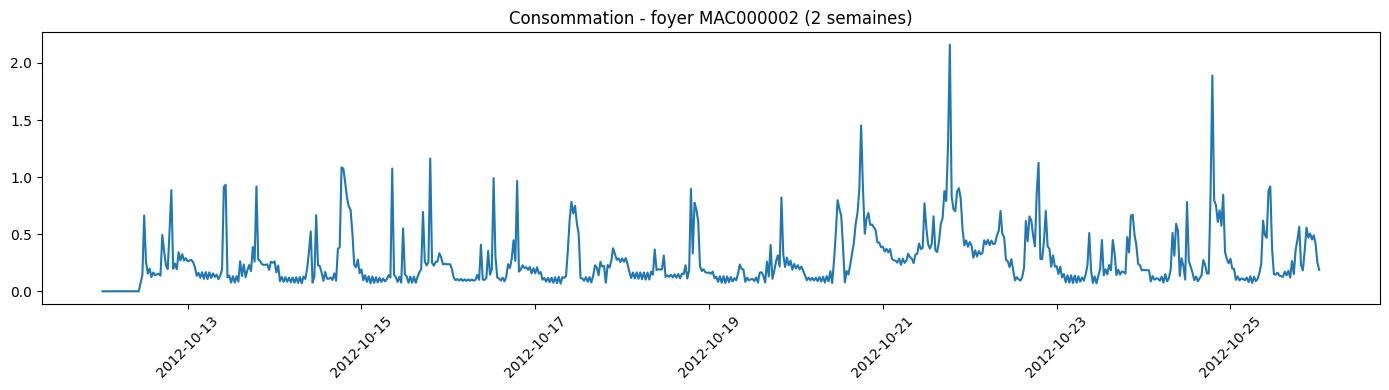

In [ ]:
import matplotlib.pyplot as plt

# Un foyer au hasard, sur 2 semaines, pour voir à quoi ressemble un vrai profil individuel
premier_foyer = df_london['LCLid'].unique()[0]
df_un_foyer = df_london[df_london['LCLid'] == premier_foyer].sort_values('tstp').head(672)  # 2 semaines

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_un_foyer['tstp'], df_un_foyer['energy(kWh/hh)'])
ax.set_title(f"Consommation - foyer {premier_foyer} (2 semaines)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

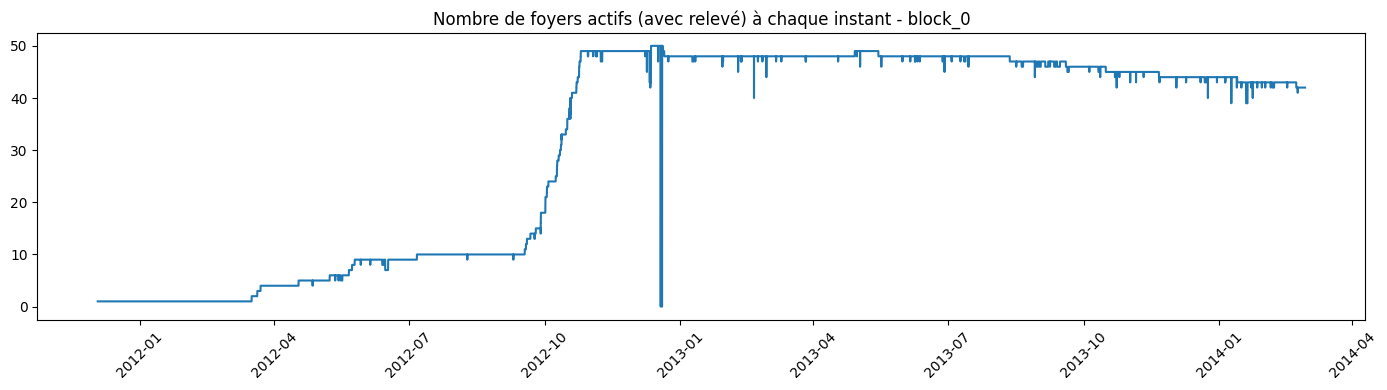

In [ ]:
# Consommation agrégée de tout le bloc (somme de tous les foyers actifs à chaque instant)
consommation_bloc = df_london.groupby('tstp')['energy(kWh/hh)'].agg(['sum', 'mean', 'count'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(consommation_bloc.index, consommation_bloc['count'])
ax.set_title("Nombre de foyers actifs (avec relevé) à chaque instant - block_0")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Retrouver les valeurs originales qui ont échoué à la conversion
df_london_brut = pd.read_csv(os.path.join(halfhourly_dir, 'block_0.csv'))
df_london_brut.columns = df_london_brut.columns.str.strip()

mask_echec = pd.to_numeric(df_london_brut['energy(kWh/hh)'], errors='coerce').isna()
print(df_london_brut.loc[mask_echec, 'energy(kWh/hh)'].value_counts())

energy(kWh/hh)
Null    50
Name: count, dtype: int64


In [ ]:
# Fenêtre de chevauchement : le départ le plus tardif et la fin la plus précoce
debut_commun = resume_foyers['min'].max()
fin_commune = resume_foyers['max'].min()
print("Fenêtre où TOUS les 50 foyers ont des données :", debut_commun, "à", fin_commune)
print("Durée :", (fin_commune - debut_commun).days, "jours")

Fenêtre où TOUS les 50 foyers ont des données : 2012-12-11 00:30:00 à 2012-12-20 23:30:00
Durée : 9 jours


In [ ]:
# Si cette fenêtre est trop courte, on regarde combien de foyers sont couverts
# sur des fenêtres plus larges mais pas 100% strictes
for date_debut_test in pd.date_range('2012-06-01', '2012-12-01', freq='MS'):
    nb_foyers_couverts = (resume_foyers['min'] <= date_debut_test).sum()
    print(f"Foyers actifs dès le {date_debut_test.date()} : {nb_foyers_couverts}/50")

Foyers actifs dès le 2012-06-01 : 9/50
Foyers actifs dès le 2012-07-01 : 9/50
Foyers actifs dès le 2012-08-01 : 10/50
Foyers actifs dès le 2012-09-01 : 10/50
Foyers actifs dès le 2012-10-01 : 18/50
Foyers actifs dès le 2012-11-01 : 49/50
Foyers actifs dès le 2012-12-01 : 49/50


In [ ]:
# Identifier le foyer tardif à exclure
foyer_tardif = resume_foyers[resume_foyers['min'] > pd.Timestamp('2012-11-01')].index.tolist()
print("Foyer(s) à exclure (démarrage tardif) :", foyer_tardif)

Foyer(s) à exclure (démarrage tardif) : ['MAC003348']


In [ ]:
# Zoom sur la chute suspecte du graphique 2
zone_suspecte = consommation_bloc.loc['2012-12-01':'2013-01-05']
print(zone_suspecte[zone_suspecte['count'] < 40])

                     sum  mean  count
tstp                                 
2012-12-18 15:13:37  0.0   NaN      0
2012-12-18 15:15:25  0.0   NaN      0
2012-12-18 15:15:30  0.0   NaN      0
2012-12-18 15:15:38  0.0   NaN      0
2012-12-18 15:16:28  0.0   NaN      0
2012-12-18 15:18:11  0.0   NaN      0
2012-12-18 15:19:39  0.0   NaN      0
2012-12-18 15:20:02  0.0   NaN      0
2012-12-18 15:20:11  0.0   NaN      0
2012-12-18 15:22:16  0.0   NaN      0
2012-12-18 15:23:00  0.0   NaN      0
2012-12-18 15:23:02  0.0   NaN      0
2012-12-18 15:23:03  0.0   NaN      0
2012-12-18 15:23:08  0.0   NaN      0
2012-12-18 15:23:11  0.0   NaN      0
2012-12-18 15:23:21  0.0   NaN      0
2012-12-18 15:23:22  0.0   NaN      0
2012-12-18 15:23:23  0.0   NaN      0
2012-12-18 15:23:26  0.0   NaN      0
2012-12-18 15:23:29  0.0   NaN      0
2012-12-18 15:23:31  0.0   NaN      0
2012-12-18 15:23:33  0.0   NaN      0
2012-12-18 15:23:42  0.0   NaN      0
2012-12-18 15:23:43  0.0   NaN      0
2012-12-18 1

In [ ]:
# Construction du sous-ensemble final : 49 foyers, fenêtre nov 2012 - fév 2014
foyers_retenus = resume_foyers[~resume_foyers.index.isin(foyer_tardif)].index.tolist()
print("Nombre de foyers retenus :", len(foyers_retenus))

df_quartier = df_london[
    (df_london['LCLid'].isin(foyers_retenus)) &
    (df_london['tstp'] >= '2012-11-01')
].copy()

print(df_quartier.shape)
print("Foyers dans le sous-ensemble final :", df_quartier['LCLid'].nunique())

Nombre de foyers retenus : 49
(1065016, 3)
Foyers dans le sous-ensemble final : 49


In [ ]:
mask_null = df_london_brut['energy(kWh/hh)'] == 'Null'
lignes_null = df_london_brut[mask_null].copy()
lignes_null['tstp'] = pd.to_datetime(lignes_null['tstp'])

print("Nombre de lignes Null :", len(lignes_null))
print("Nombre de timestamps uniques parmi elles :", lignes_null['tstp'].nunique())
print(lignes_null[['LCLid', 'tstp']].sort_values('tstp').head(50))

Nombre de lignes Null : 50
Nombre de timestamps uniques parmi elles : 45
             LCLid                tstp
42441    MAC000246 2012-12-18 15:13:37
1141246  MAC004387 2012-12-18 15:15:25
1175253  MAC004431 2012-12-18 15:15:30
76341    MAC000450 2012-12-18 15:15:38
1207964  MAC005492 2012-12-18 15:16:28
94080    MAC001074 2012-12-18 15:18:11
1045277  MAC004179 2012-12-18 15:19:39
1076114  MAC004247 2012-12-18 15:20:02
1107005  MAC004319 2012-12-18 15:20:11
1021994  MAC004034 2012-12-18 15:22:16
98616    MAC003223 2012-12-18 15:23:00
123942   MAC003239 2012-12-18 15:23:02
149094   MAC003252 2012-12-18 15:23:03
173986   MAC003281 2012-12-18 15:23:08
199021   MAC003305 2012-12-18 15:23:11
245131   MAC003388 2012-12-18 15:23:21
269975   MAC003394 2012-12-18 15:23:22
294670   MAC003400 2012-12-18 15:23:23
343572   MAC003423 2012-12-18 15:23:26
368209   MAC003428 2012-12-18 15:23:26
319358   MAC003422 2012-12-18 15:23:26
392807   MAC003449 2012-12-18 15:23:29
417449   MAC003463 2012-12-18 

In [ ]:
# Reconstruction de df_quartier propre : on retire d'abord les lignes au timestamp corrompu
df_quartier_v2 = df_quartier[~df_quartier['tstp'].isin(lignes_null['tstp'].unique())].copy()
print("Lignes retirées :", len(df_quartier) - len(df_quartier_v2))

# Grille de référence théorique : toutes les demi-heures entre début et fin de la fenêtre
grille_reference = pd.date_range('2012-11-01 00:00:00', '2014-02-28 00:00:00', freq='30min')
print("Nombre de créneaux théoriques :", len(grille_reference))
print("Nombre de créneaux théoriques x 49 foyers :", len(grille_reference) * 49)
print("Nombre de lignes réelles :", len(df_quartier_v2))
print("Taux de complétude global :", len(df_quartier_v2) / (len(grille_reference) * 49) * 100, "%")

Lignes retirées : 49
Nombre de créneaux théoriques : 23233
Nombre de créneaux théoriques x 49 foyers : 1138417
Nombre de lignes réelles : 1064967
Taux de complétude global : 93.54805840039283 %


In [ ]:
# Détail par foyer : combien de créneaux manquent réellement à chacun ?
completude_par_foyer = df_quartier_v2.groupby('LCLid')['tstp'].count()
completude_par_foyer_pct = (completude_par_foyer / len(grille_reference) * 100).sort_values()
print(completude_par_foyer_pct.describe())
print(completude_par_foyer_pct.head(10))  # les foyers les moins complets

count     49.000000
mean      93.548058
std       17.355412
min       10.123531
25%       99.767572
50%       99.978479
75%       99.991392
max      100.000000
Name: tstp, dtype: float64
LCLid
MAC001074    10.123531
MAC000450    40.274609
MAC003463    58.666552
MAC004034    66.422761
MAC003718    72.100030
MAC005492    73.137348
MAC003557    79.524814
MAC003775    90.487668
MAC003422    98.110446
MAC003252    98.342874
Name: tstp, dtype: float64


In [ ]:
print("Max de energy(kWh/hh) sur tout le quartier :", df_quartier_v2['energy(kWh/hh)'].max())
# 1 kWh/hh = une puissance moyenne de 2kW sur la demi-heure ; un pic à 8 kWh/hh = 16kW,
# plausible pour un foyer avec chauffage électrique + douche électrique instantanée au même moment

Max de energy(kWh/hh) sur tout le quartier : 8.1709995


In [ ]:
SEUIL_COMPLETUDE = 95.0

foyers_a_exclure = completude_par_foyer_pct[completude_par_foyer_pct < SEUIL_COMPLETUDE].index.tolist()
print("Foyers exclus pour complétude insuffisante :", foyers_a_exclure)
print("Nombre exclus :", len(foyers_a_exclure))
print("Nombre de foyers retenus au final :", 49 - len(foyers_a_exclure))

Foyers exclus pour complétude insuffisante : ['MAC001074', 'MAC000450', 'MAC003463', 'MAC004034', 'MAC003718', 'MAC005492', 'MAC003557', 'MAC003775']
Nombre exclus : 8
Nombre de foyers retenus au final : 41


In [ ]:
# Dataset final : foyers retenus, fenêtre commune, sans les lignes corrompues
df_quartier_final = df_quartier_v2[
    ~df_quartier_v2['LCLid'].isin(foyers_a_exclure)
].copy()

print("Shape finale :", df_quartier_final.shape)
print("Foyers dans le dataset final :", df_quartier_final['LCLid'].nunique())

Shape finale : (950954, 3)
Foyers dans le dataset final : 41


In [ ]:
def combler_trous_foyer(df_foyer, grille, limite_creneaux=8):
    df_foyer = df_foyer.set_index('tstp').reindex(grille)
    df_foyer['energy(kWh/hh)'] = df_foyer['energy(kWh/hh)'].interpolate(
        method='linear', limit=limite_creneaux, limit_area='inside')
    df_foyer['LCLid'] = df_foyer['LCLid'].ffill().bfill()
    return df_foyer.reset_index().rename(columns={'index': 'tstp'})

liste_foyers_propres = []
for lclid, groupe in df_quartier_final.groupby('LCLid'):
    liste_foyers_propres.append(combler_trous_foyer(groupe, grille_reference))

df_quartier_clean = pd.concat(liste_foyers_propres, ignore_index=True)

print("NaN restants :", df_quartier_clean['energy(kWh/hh)'].isna().sum())
print("Shape finale :", df_quartier_clean.shape)
print("Foyers :", df_quartier_clean['LCLid'].nunique())

NaN restants : 1304
Shape finale : (952553, 3)
Foyers : 41


In [ ]:
# Répartition des NaN restants par foyer
nan_par_foyer = df_quartier_clean[df_quartier_clean['energy(kWh/hh)'].isna()].groupby('LCLid').size().sort_values(ascending=False)
print(nan_par_foyer)
print("\nNombre de foyers concernés :", len(nan_par_foyer))

LCLid
MAC003422    376
MAC003252    368
MAC003394    120
MAC003423     80
MAC000002     40
MAC003449     40
MAC003566     40
MAC003597     40
MAC003656     40
MAC003680     40
MAC003844     40
MAC003856     40
MAC003874     40
dtype: int64

Nombre de foyers concernés : 13


In [ ]:
# Localisation temporelle : sont-ils groupés en quelques trous longs, ou dispersés ?
df_nan = df_quartier_clean[df_quartier_clean['energy(kWh/hh)'].isna()].sort_values(['LCLid', 'tstp'])

for lclid, groupe in df_nan.groupby('LCLid'):
    ecarts = groupe['tstp'].diff().dt.total_seconds() / 1800  # en nombre de créneaux de 30min
    nb_blocs = (ecarts != 1).sum() + 1  # +1 pour le premier bloc
    print(f"{lclid} : {len(groupe)} NaN au total, répartis en environ {nb_blocs} bloc(s) distinct(s), du {groupe['tstp'].min()} au {groupe['tstp'].max()}")

MAC000002 : 40 NaN au total, répartis en environ 2 bloc(s) distinct(s), du 2012-11-08 04:30:00 au 2012-11-09 00:00:00
MAC003252 : 368 NaN au total, répartis en environ 4 bloc(s) distinct(s), du 2012-11-08 04:30:00 au 2014-02-28 00:00:00
MAC003394 : 120 NaN au total, répartis en environ 4 bloc(s) distinct(s), du 2013-08-20 04:30:00 au 2014-02-07 00:00:00
MAC003422 : 376 NaN au total, répartis en environ 8 bloc(s) distinct(s), du 2013-09-01 04:30:00 au 2013-12-23 00:00:00
MAC003423 : 80 NaN au total, répartis en environ 3 bloc(s) distinct(s), du 2012-12-11 04:30:00 au 2014-01-20 00:00:00
MAC003449 : 40 NaN au total, répartis en environ 2 bloc(s) distinct(s), du 2012-12-11 04:30:00 au 2012-12-12 00:00:00
MAC003566 : 40 NaN au total, répartis en environ 2 bloc(s) distinct(s), du 2012-12-11 04:30:00 au 2012-12-12 00:00:00
MAC003597 : 40 NaN au total, répartis en environ 2 bloc(s) distinct(s), du 2014-01-19 04:30:00 au 2014-01-20 00:00:00
MAC003656 : 40 NaN au total, répartis en environ 2 bl

In [ ]:
print("Complétude de MAC003422 :", completude_par_foyer_pct['MAC003422'], "%")
print("Complétude de MAC003252 :", completude_par_foyer_pct['MAC003252'], "%")

Complétude de MAC003422 : 98.11044634786725 %
Complétude de MAC003252 : 98.34287435974692 %


In [ ]:
df_quartier_clean['etait_manquant'] = df_quartier_clean['energy(kWh/hh)'].isna()

df_quartier_clean.to_csv('/content/london_quartier_clean.csv', index=False)
df_quartier_clean.to_csv('/content/drive/MyDrive/EnergyMind_TSYP14/data/london_quartier_clean.csv', index=False)

print("Dataset final :", df_quartier_clean.shape)
print("Foyers :", df_quartier_clean['LCLid'].nunique())
print("NaN restants (trous longs documentés, volontairement conservés) :", df_quartier_clean['energy(kWh/hh)'].isna().sum())

Dataset final : (952553, 4)
Foyers : 41
NaN restants (trous longs documentés, volontairement conservés) : 1304
